# 03 – EDA & Visualisation

This notebook explores the cleaned Kepler and TESS datasets in `data/processed/`.
We review key distributions and relationships used later for modeling,
and save a few standard figures into `figures/` for reuse.

- Load processed CSVs (kepler_clean.csv, tess_clean.csv)
- Inspect units & consistency across Kepler and TESS catalogs
- Apply physical plausibility filters (e.g. radius, Teq, insolation) to remove outliers
- Plot distributions of planet radius and orbital period (log-scale)
- Scatter plots:
  - Planet Radius vs. Orbital Period
  - Planet Radius vs. Stellar Insolation Flux
- Host star context: 
  - Host Star Teff vs. Planet Radius
  - Stellar Radius vs. Orbital Period

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# project paths (notebooks/ -> project root)
PROJECT_ROOT = Path("..").resolve()
PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# allow importing from src/ if needed later
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option("display.max_columns", 50)

In [2]:
kepler = pd.read_csv(PROCESSED / "kepler_clean.csv")
tess   = pd.read_csv(PROCESSED / "tess_clean.csv")

kepler.shape, tess.shape, kepler.columns.tolist()[:6]

((9564, 16),
 (7116, 17),
 ['star_id',
  'planet_id',
  'disposition',
  'orbital_period',
  'transit_duration',
  'transit_depth'])

In [3]:
print("Kepler label counts:\n", kepler["disposition"].value_counts(), "\n")
print("TESS   label counts (aligned):\n", tess["disposition_aligned"].value_counts(),"\n")

display(kepler.describe(include="all").T.head(12))
display(tess.describe(include="all").T.head(12))

Kepler label counts:
 disposition
FALSE POSITIVE    4839
CONFIRMED         2746
CANDIDATE         1979
Name: count, dtype: int64 

TESS   label counts (aligned):
 disposition_aligned
CANDIDATE         5139
FALSE POSITIVE    1294
CONFIRMED          683
Name: count, dtype: int64 



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
star_id,9564.0,NaN,NaN,NaN,7690628.327373,2653459.080974,757450.0,5556034.25,7906892.0,9873066.5,12935144.0
planet_id,9564,9564,K00001.01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
disposition,9564,3,FALSE POSITIVE,4839,NaN,NaN,NaN,NaN,NaN,NaN,NaN
orbital_period,9564.0,NaN,NaN,NaN,75.671358,1334.744046,0.241843,2.733684,9.752831,40.715178,129995.7784
transit_duration,9564.0,NaN,NaN,NaN,5.621606,6.471554,0.052,2.43775,3.7926,6.2765,138.54
transit_depth,9201.0,NaN,NaN,NaN,23791.335898,82242.683149,0.0,159.9,421.1,1473.4,1541400.0
planet_radius,9201.0,NaN,NaN,NaN,102.891778,3077.639126,0.08,1.4,2.39,14.93,200346.0
equilibrium_temp,9201.0,NaN,NaN,NaN,1085.385828,856.351161,25.0,539.0,878.0,1379.0,14667.0
insolation_flux,9243.0,NaN,NaN,NaN,7745.737023,159204.6652,0.0,20.15,141.6,870.29,10947554.55
snr,9201.0,NaN,NaN,NaN,259.895001,795.806615,0.0,12.0,23.0,78.0,9054.7


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
planet_id,7116.0,NaN,NaN,NaN,3781.756842,2127.683859,118.01,1962.76,3754.51,5624.0125,7505.01
star_id,7116.0,NaN,NaN,NaN,248367131.346684,163116132.991664,2876.0,137480798.75,253090580.5,355464632.75,2041563029.0
disposition,7116,5,PC,4678,NaN,NaN,NaN,NaN,NaN,NaN,NaN
orbital_period,7019.0,NaN,NaN,NaN,18.732509,101.581975,0.152076,2.471204,4.15962,8.169113,1837.889731
transit_duration,7116.0,NaN,NaN,NaN,3.045829,1.892067,0.101,1.811326,2.714,3.801071,30.015619
transit_depth,7116.0,NaN,NaN,NaN,8013.959031,17930.122037,24.583493,1337.118578,4450.0,9717.895065,767910.313098
planet_radius,6617.0,NaN,NaN,NaN,10.194181,8.744853,0.552507,4.276245,10.2109,13.8556,297.111726
equilibrium_temp,6810.0,NaN,NaN,NaN,1283.50472,702.108989,37.0,804.322694,1173.0,1591.925593,6413.0
insolation_flux,6944.0,NaN,NaN,NaN,2341.485731,11330.44931,0.000342,79.643775,350.488,1153.417742,280833.0
stellar_teff,6955.0,NaN,NaN,NaN,5803.303461,1523.250963,2808.0,5203.0,5809.0,6308.31,50000.0


In [4]:
def hist(df, col, title, fname, bins=50, logx=False):
    s = df[col].dropna()
    if logx:
        s = np.log10(s[s > 0])
    plt.figure()
    plt.hist(s, bins=bins)
    plt.title(title)
    plt.xlabel(("log10 " if logx else "") + col)
    plt.ylabel("count")
    plt.tight_layout()
    plt.savefig(FIGURES / fname, dpi=150)
    plt.show()

def scatter(df, x, y, c=None, title=None, fname=None, logx=False, logy=False, alpha=0.6):
    sub = df[[x, y] + ([c] if c else [])].dropna()
    plt.figure()
    if c:
        for lab, grp in sub.groupby(c):
            plt.scatter(grp[x], grp[y], label=str(lab), s=12, alpha=alpha)
        plt.legend(title=c)
    else:
        plt.scatter(sub[x], sub[y], s=12, alpha=alpha)
    if logx: plt.xscale("log")
    if logy: plt.yscale("log")
    plt.xlabel(x); plt.ylabel(y)
    if title: plt.title(title)
    plt.tight_layout()
    if fname:
        plt.savefig(FIGURES / fname, dpi=150)
    plt.show()

In [5]:
kepler["planet_radius"].describe(percentiles=[0.5, 0.9, 0.99])

count      9201.000000
mean        102.891778
std        3077.639126
min           0.080000
50%           2.390000
90%          52.840000
99%         369.200000
max      200346.000000
Name: planet_radius, dtype: float64

In [6]:
tess["planet_radius"].describe(percentiles=[0.5, 0.9, 0.99])

count    6617.000000
mean       10.194181
std         8.744853
min         0.552507
50%        10.210900
90%        17.585560
99%        28.286904
max       297.111726
Name: planet_radius, dtype: float64

In [7]:
from typing import Optional, Tuple, Dict
import numpy as np
import pandas as pd

def filter_physical(
    df: pd.DataFrame,
    *,
    # column names (adapt if yours differ)
    col_radius: str = "planet_radius",            # R_earth
    col_teq: str = "equilibrium_temp",            # K
    col_insol: Optional[str] = "insolation_flux", # S_earth
    col_period: Optional[str] = "orbital_period", # days
    col_dur: Optional[str] = "transit_duration",  # hours
    col_depth: Optional[str] = "transit_depth",   # ppm
    col_st_teff: Optional[str] = "stellar_teff",  # K
    col_st_logg: Optional[str] = "stellar_logg",  # log10(cm/s^2)
    col_st_rad: Optional[str] = "stellar_radius", # R_sun
    # numeric bounds (feel free to tweak)
    bounds: Dict[str, Tuple[Optional[float], Optional[float]]] = None,
    drop_na_in: Tuple[str, ...] = (),             # columns where NA => drop
) -> pd.DataFrame:
    """
    Return a copy of df filtered by physically plausible ranges.
    Only rows are filtered; ALL columns are preserved.
    """
    if bounds is None:
        bounds = {
            # planets
            "planet_radius":      (0.5, 30),      # R_earth (Jupiter ~11.2)
            "equilibrium_temp":   (50, 5000),     # K
            "insolation_flux":    (1e-4, 1e5),    # relative to Earth; wide to keep hot TOIs
            "orbital_period":     (0.1, 1000),    # days
            "transit_duration":   (0.2, 50),      # hours
            "transit_depth":      (10, 500000),   # ppm (10 ppm to 50% = 5e5 ppm)
            # host stars
            "stellar_teff":       (2500, 12000),  # K (M to early A)
            "stellar_logg":       (3.0, 5.5),     # dwarfs/subgiants; exclude giants if wanted
            "stellar_radius":     (0.1, 10),      # R_sun
        }

    # build a boolean mask starting all True
    mask = pd.Series(True, index=df.index)

    def apply_bound(col_name, key):
        nonlocal mask
        if col_name is None or col_name not in df.columns: 
            return
        lo, hi = bounds.get(key, (None, None))
        s = df[col_name]
        if lo is not None:
            mask &= (s >= lo)
        if hi is not None:
            mask &= (s <= hi)

    # apply on configured columns
    apply_bound(col_radius,   "planet_radius")
    apply_bound(col_teq,      "equilibrium_temp")
    apply_bound(col_insol,    "insolation_flux")
    apply_bound(col_period,   "orbital_period")
    apply_bound(col_dur,      "transit_duration")
    apply_bound(col_depth,    "transit_depth")
    apply_bound(col_st_teff,  "stellar_teff")
    apply_bound(col_st_logg,  "stellar_logg")
    apply_bound(col_st_rad,   "stellar_radius")

    # drop rows with NA in important columns (optional)
    if drop_na_in:
        mask &= df[list(drop_na_in)].notna().all(axis=1)

    out = df.loc[mask].copy()
    return out

In [8]:
# Keep everything else identical, just filter rows to remove absurd outliers
kepler_phys = filter_physical(
    kepler,
    drop_na_in=("planet_radius","orbital_period")  # require these, optional
)
tess_phys = filter_physical(
    tess,
    drop_na_in=("planet_radius","orbital_period")
)

print("Kepler:", kepler.shape, "->", kepler_phys.shape)
print("TESS  :", tess.shape,   "->", tess_phys.shape)

Kepler: (9564, 16) -> (7365, 16)
TESS  : (7116, 17) -> (5982, 17)


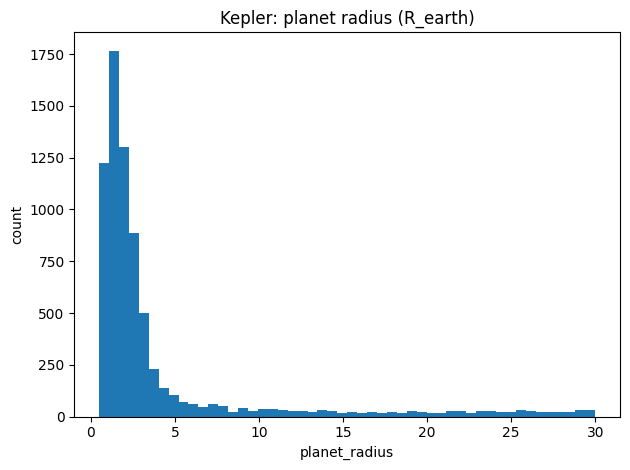

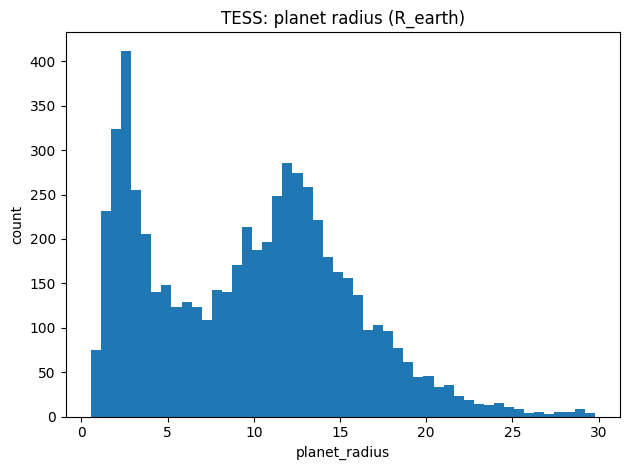

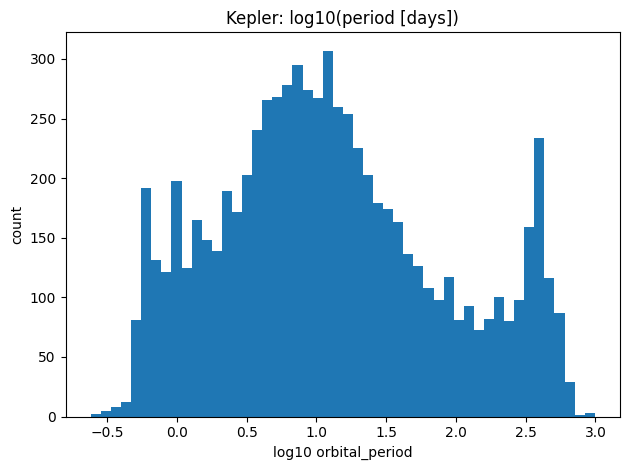

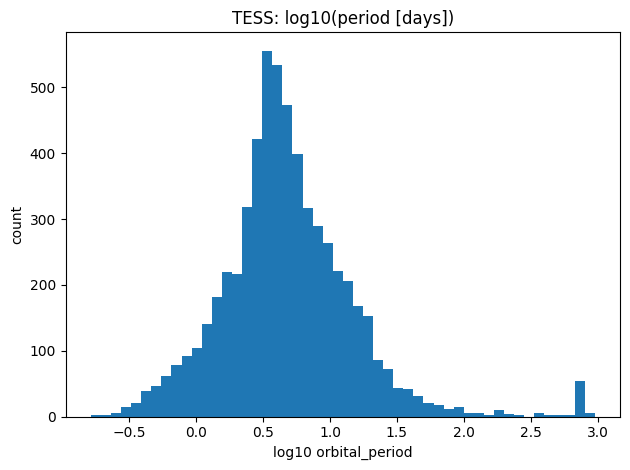

In [9]:
# Planet radius
hist(kepler_phys, "planet_radius", "Kepler: planet radius (R_earth)", "k_radius.png")
hist(tess_phys,   "planet_radius", "TESS: planet radius (R_earth)",   "t_radius.png")

# Orbital period (log-scale: wide range)
hist(kepler_phys, "orbital_period", "Kepler: log10(period [days])", "k_period_log.png", logx=True)
hist(tess_phys,   "orbital_period", "TESS: log10(period [days])",   "t_period_log.png", logx=True)

| log10(P) | P (days)  | Equivalent time         |
| -------- | --------- | ----------------------- |
| **0.0**  | 1 day     | 24 hours                |
| **0.3**  | 2 days    | weekend trip            |
| **0.5**  | 3.2 days  | ~half a week            |
| **1.0**  | 10 days   | ~1.5 weeks              |
| **1.5**  | 32 days   | ~1 month                |
| **2.0**  | 100 days  | ~3.3 months             |
| **2.5**  | 316 days  | ~10.5 months (≈ 1 year) |
| **3.0**  | 1000 days | ~2.7 years              |


### Planet Radius vs. Orbital Period (log–log)

This plot compares planet radius with orbital period for Kepler and TESS.
The log–log scale highlights the wide dynamic range of both variables.
- Clusters:

  - Small, short-period planets (compact multi-planet systems).
  - Inflated giants (“hot Jupiters”) with large radii and very short periods.

- Bias: Detection favors short periods (multiple transits within the mission lifetime).

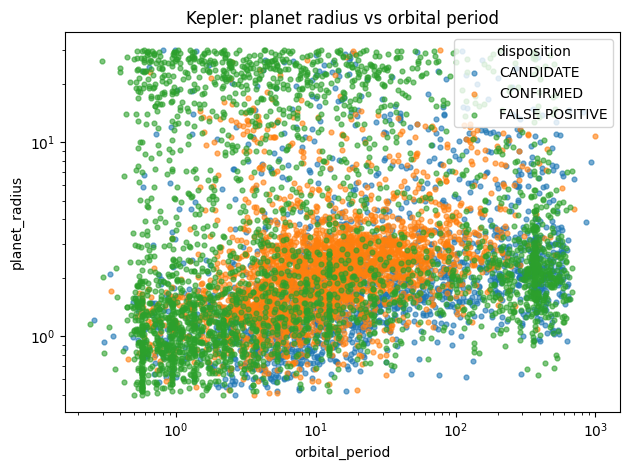

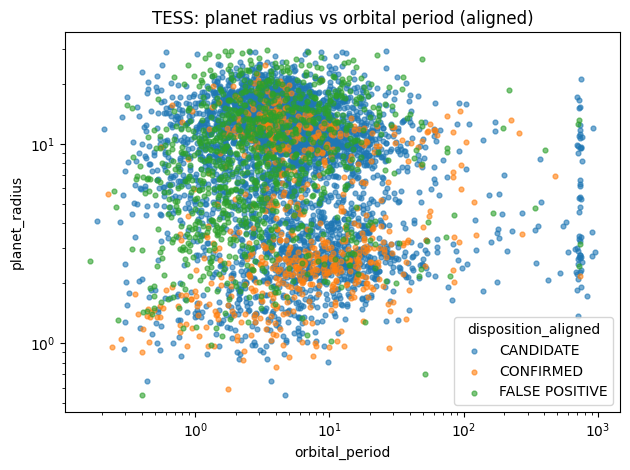

In [13]:
scatter(
    kepler_phys, x="orbital_period", y="planet_radius", c="disposition",
    title="Kepler: planet radius vs orbital period", fname="k_radius_vs_period.png",
    logx=True, logy=True, alpha=0.6
)

scatter(
    tess_phys, x="orbital_period", y="planet_radius", c="disposition_aligned",
    title="TESS: planet radius vs orbital period (aligned)", fname="t_radius_vs_period.png",
    logx=True, logy=True, alpha=0.6
)

### Planet Radius vs. Stellar Insolation Flux (log–log)

This is the classic diagram used to reveal the “radius valley”.

- X-axis: Stellar flux received relative to Earth (log).

- Y-axis: Planet radius (log).

- Feature: A relative scarcity of planets in the ~1.5–2 R⊕ regime at moderate flux values.

- Interpretation: Likely caused by photoevaporation or core-powered mass loss stripping planetary envelopes.

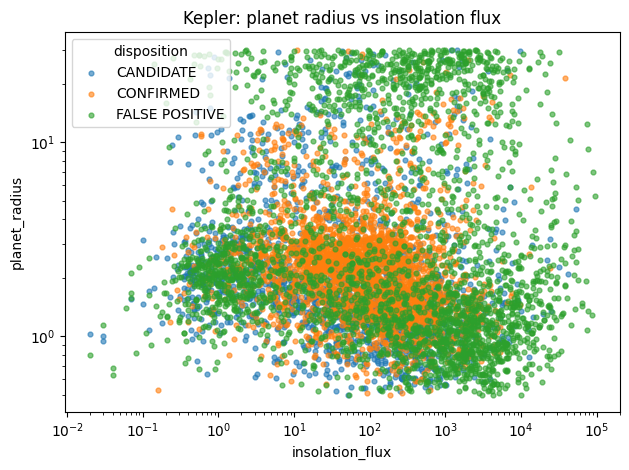

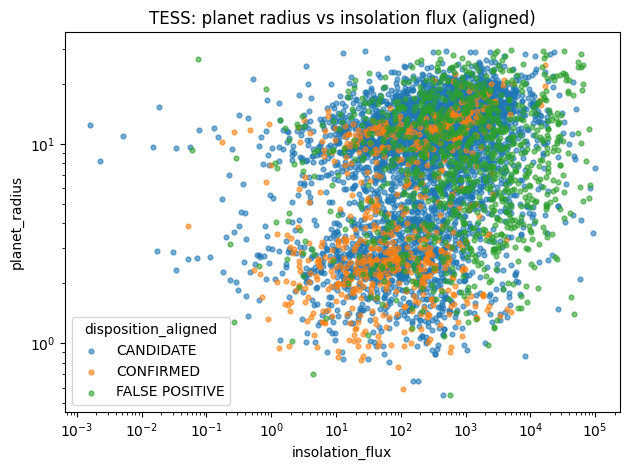

In [14]:
scatter(
    kepler_phys, x="insolation_flux", y="planet_radius", c="disposition",
    title="Kepler: planet radius vs insolation flux", fname="k_radius_vs_insol.png",
    logx=True, logy=True, alpha=0.6
)

scatter(
    tess_phys, x="insolation_flux", y="planet_radius", c="disposition_aligned",
    title="TESS: planet radius vs insolation flux (aligned)", fname="t_radius_vs_insol.png",
    logx=True, logy=True, alpha=0.6
)

### Host Star Teff vs. Planet Radius (linear–linear)

This plot explores the relation between stellar effective temperature and planet size.

- Cool stars (M/K dwarfs): tend to host smaller planets, easier to detect due to larger transit depths.

- Hotter stars (F/A types): more giant planets detected, but fewer small planets (diluted transits).

- This gives insight into stellar environment biases in exoplanet detection.

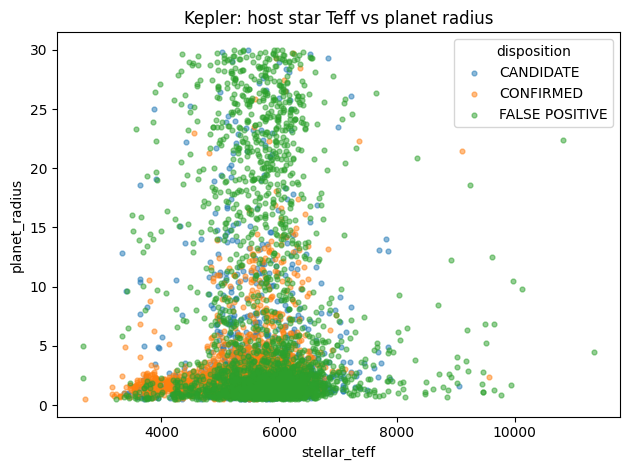

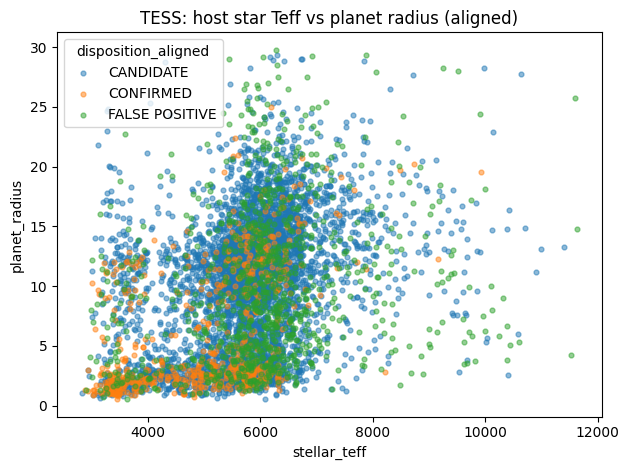

In [15]:
scatter(
    kepler_phys, x="stellar_teff", y="planet_radius", c="disposition",
    title="Kepler: host star Teff vs planet radius", fname="k_teff_vs_radius.png",
    logx=False, logy=False, alpha=0.5
)

scatter(
    tess_phys, x="stellar_teff", y="planet_radius", c="disposition_aligned",
    title="TESS: host star Teff vs planet radius (aligned)", fname="t_teff_vs_radius.png",
    logx=False, logy=False, alpha=0.5
)

### Stellar Radius vs. Orbital Period (log–log)

This plot shows how the size of the host star correlates with orbital period of detected planets.

- Small stars: allow detection of smaller planets, often at short periods.

- Large stars: dilute transit depths, making only large or close-in planets observable.

- Bias difference: TESS favors bright, smaller stars compared to Kepler’s deeper but narrower field.

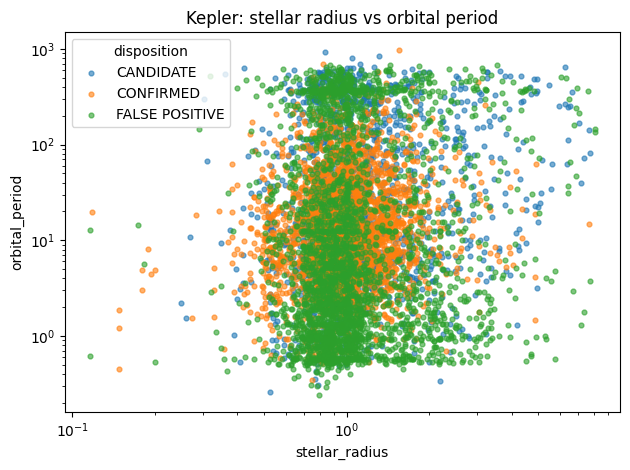

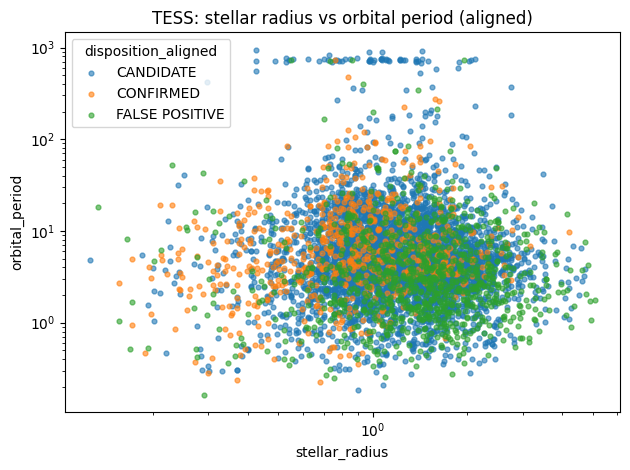

In [16]:
scatter(
    kepler_phys, x="stellar_radius", y="orbital_period", c="disposition",
    title="Kepler: stellar radius vs orbital period", fname="k_stellarR_vs_period.png",
    logx=True, logy=True, alpha=0.6
)

scatter(
    tess_phys, x="stellar_radius", y="orbital_period", c="disposition_aligned",
    title="TESS: stellar radius vs orbital period (aligned)", fname="t_stellarR_vs_period.png",
    logx=True, logy=True, alpha=0.6
)